# Setup dan Import Library

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import sys
sys.path.insert(0, os.path.abspath('..'))
from src.retrieval.fusion import reciprocal_rank_fusion, get_top_k
from src.retrieval.evaluation import (
    ndcg_at_k, mean_reciprocal_rank, recall_at_k,
    mean_average_precision, cohens_kappa, cohens_kappa_per_query,
    evaluate_all_metrics
)
from src.retrieval.preprocessing import (
    create_stemmer, create_stopword_remover,
    clean_text_semantic, clean_text_lexical
)
from src.retrieval.retrieval import HybridRetriever

INDEX_DIR = '../index'
EVAL_DIR  = '../data'
print("✅ Import selesai")

✅ Import selesai


# Load Index

In [2]:
df               = pd.read_pickle(f'{INDEX_DIR}/dataset_processed.pkl')
tfidf_data       = pickle.load(open(f'{INDEX_DIR}/tfidf.pkl', 'rb'))
bm25             = pickle.load(open(f'{INDEX_DIR}/bm25.pkl', 'rb'))
faiss_index      = faiss.read_index(f'{INDEX_DIR}/dense.faiss')
sbert_model      = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
stemmer          = create_stemmer()
stopword_remover = create_stopword_remover()

retriever = HybridRetriever(
    tfidf_data['vectorizer'], tfidf_data['matrix'],
    bm25, faiss_index, sbert_model, stemmer, stopword_remover
)
print("✅ Retriever siap")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Retriever siap


# Definisi 30 Query Uji

In [3]:
TEST_QUERIES = [
    "Kawah Putih Bandung", "Candi Borobudur Magelang", "Pantai Ancol Jakarta",
    "Kebun Binatang Ragunan Jakarta", "museum batik Yogyakarta", "Taman Mini Indonesia Indah Jakarta",
    "Kawah Rengganis Cibuni Bandung", "Gunung Tangkuban Perahu Bandung",
    "tempat menenangkan pikiran dengan alam", "wisata alam yang cocok untuk meditasi",
    "destinasi petualangan outdoor seru", "liburan romantis pemandangan alam indah",
    "tempat belajar sejarah budaya Jawa", "wisata edukasi untuk anak-anak",
    "pantai untuk snorkeling melihat terumbu karang", "gunung untuk pendakian pemula",
    "tempat belanja oleh-oleh khas daerah", "taman hiburan seru untuk keluarga",
    "air terjun tersembunyi", "wisata religi tempat ibadah",
    "kuliner dan wisata di Bandung", "hutan pinus dan wisata alam",
    "wisata murah meriah untuk backpacker", "resort dan penginapan alam mewah",
    "spot foto aesthetic kekinian", "kegiatan water sport di laut",
    "wisata malam kota Jakarta", "camping dengan pemandangan alam",
    "danau di Jawa Tengah", "wisata sejarah perjuangan kemerdekaan",
]

print(f"Total query uji: {len(TEST_QUERIES)}")
for i, q in enumerate(TEST_QUERIES, 1):
    print(f"  {i:2d}. {q}")

Total query uji: 30
   1. Kawah Putih Bandung
   2. Candi Borobudur Magelang
   3. Pantai Ancol Jakarta
   4. Kebun Binatang Ragunan Jakarta
   5. museum batik Yogyakarta
   6. Taman Mini Indonesia Indah Jakarta
   7. Kawah Rengganis Cibuni Bandung
   8. Gunung Tangkuban Perahu Bandung
   9. tempat menenangkan pikiran dengan alam
  10. wisata alam yang cocok untuk meditasi
  11. destinasi petualangan outdoor seru
  12. liburan romantis pemandangan alam indah
  13. tempat belajar sejarah budaya Jawa
  14. wisata edukasi untuk anak-anak
  15. pantai untuk snorkeling melihat terumbu karang
  16. gunung untuk pendakian pemula
  17. tempat belanja oleh-oleh khas daerah
  18. taman hiburan seru untuk keluarga
  19. air terjun tersembunyi
  20. wisata religi tempat ibadah
  21. kuliner dan wisata di Bandung
  22. hutan pinus dan wisata alam
  23. wisata murah meriah untuk backpacker
  24. resort dan penginapan alam mewah
  25. spot foto aesthetic kekinian
  26. kegiatan water sport di laut
  

# Jalankan Retrieval untuk Semua Query

In [4]:
from tqdm import tqdm

results_all     = {}   # {query: {'hybrid':[...], 'tfidf':[...], 'bm25':[...], 'dense':[...]}}
pool_per_query  = {}   # {query: [doc_idx_1, doc_idx_2, ...]} ← gabungan UNIK dari 4 metode

for query in tqdm(TEST_QUERIES, desc="Retrieving & Building Pool"):
    res = retriever.hybrid(query, top_k=10)
    results_all[query] = res

    # === Depth-K Pooling: gabungkan unik dari keempat metode ===
    seen = set()
    pool = []
    for method_results in [res['hybrid'], res['tfidf'], res['bm25'], res['dense']]:
        for doc_idx in method_results:
            if doc_idx not in seen:
                seen.add(doc_idx)
                pool.append(doc_idx)
    pool_per_query[query] = pool

with open(f'{EVAL_DIR}/retrieval_results.json', 'w') as f:
    json.dump(results_all, f, indent=2)
with open(f'{EVAL_DIR}/pool_per_query.json', 'w') as f:
    json.dump(pool_per_query, f, indent=2)

print(f"✅ Retrieval & pooling selesai untuk {len(TEST_QUERIES)} query")
print(f"💾 Tersimpan di {EVAL_DIR}/retrieval_results.json dan pool_per_query.json")
print(f"\nContoh ukuran pool:")
for q in TEST_QUERIES[:3]:
    print(f"   '{q}': {len(pool_per_query[q])} dokumen unik")

Retrieving & Building Pool: 100%|██████████| 30/30 [00:01<00:00, 25.52it/s]

✅ Retrieval & pooling selesai untuk 30 query
💾 Tersimpan di ../data/retrieval_results.json dan pool_per_query.json

Contoh ukuran pool:
   'Kawah Putih Bandung': 20 dokumen unik
   'Candi Borobudur Magelang': 18 dokumen unik
   'Pantai Ancol Jakarta': 21 dokumen unik


# Inference Anotasi Manual

Dokumen dianggap Relevan (1) jika minimal salah satu terpenuhi:

Exact match dengan nama tempat di query, ATAU
Kategori sama DAN kota sama dengan yang diimplikasikan query (mis. "Kawah Putih Bandung" → kategori Cagar Alam, kota Bandung)

Tidak Relevan (0) jika:

Kota berbeda dari yang diimplikasikan query, meskipun kategori sama
Kategori berbeda, meskipun kota sama

In [5]:
ANNOTATOR_NAME  = "annotator_1"
ANNOTATION_FILE = f'{EVAL_DIR}/annotations_{ANNOTATOR_NAME}.json'

if os.path.exists(ANNOTATION_FILE):
    with open(ANNOTATION_FILE, 'r') as f:
        annotations = json.load(f)
    print(f"📂 Melanjutkan anotasi: {len(annotations)}/{len(TEST_QUERIES)} query")
else:
    annotations = {}
    print("📝 Memulai anotasi baru")

remaining_queries = [q for q in TEST_QUERIES if q not in annotations]
print(f"📋 Sisa query untuk dianotasi: {len(remaining_queries)}")

if not remaining_queries:
    print("🎉 Semua query sudah dianotasi!")
else:
    current_query_idx = [0]
    output = widgets.Output()   # ← container tunggal, di-display sekali saja
    display(output)

    def show_next_query():
        with output:
            clear_output(wait=True)
            if current_query_idx[0] >= len(remaining_queries):
                print("🎉 Semua query sudah dianotasi!")
                return

            query = remaining_queries[current_query_idx[0]]
            doc_indices = pool_per_query[query]

            print("━" * 60)
            print(f"📋 Query {current_query_idx[0]+1}/{len(remaining_queries)}: '{query}'")
            print("━" * 60)
            print(f"\nPool berisi {len(doc_indices)} dokumen unik:\n")

            doc_display = df.iloc[doc_indices][['Place_Name', 'City', 'Category', 'Description']].copy()
            for rank, (_, row) in enumerate(doc_display.iterrows(), 1):
                desc_snippet = str(row['Description'])[:100] + '...'
                print(f"  [{rank:2d}] {row['Place_Name']} ({row['City']}) - {row['Category']}")
                print(f"       {desc_snippet}\n")

            annotation_inputs = [
                widgets.ToggleButtons(
                    options=['Relevan (1)', 'Tidak Relevan (0)'],
                    value='Tidak Relevan (0)',
                    description=f'Doc {i+1}:',
                    style={'description_width': '60px'}
                )
                for i in range(len(doc_indices))
            ]
            save_btn = widgets.Button(description="Simpan & Lanjut →", button_style='success')

            def on_save(b, query=query, doc_indices=doc_indices, annotation_inputs=annotation_inputs):
                query_annot = {
                    str(doc_id): (1 if inp.value == 'Relevan (1)' else 0)
                    for doc_id, inp in zip(doc_indices, annotation_inputs)
                }
                annotations[query] = query_annot
                with open(ANNOTATION_FILE, 'w') as f:
                    json.dump(annotations, f, indent=2)
                current_query_idx[0] += 1
                show_next_query()

            save_btn.on_click(on_save)
            display(widgets.VBox(annotation_inputs + [save_btn]))

    show_next_query()

📂 Melanjutkan anotasi: 30/30 query
📋 Sisa query untuk dianotasi: 0
🎉 Semua query sudah dianotasi!


# Hitung Semua Metrik Evaluasi

In [6]:
# Load anotasi (format: {query: {doc_id_str: 0/1}})
with open(ANNOTATION_FILE, 'r') as f:
    annotations = json.load(f)

annotated_queries = list(annotations.keys())
print(f"Total query teranotasi: {len(annotated_queries)}")

methods = ['hybrid', 'tfidf', 'bm25', 'dense']
K = 10

eval_results = {}

for method in methods:
    relevances_per_query = {}
    total_relevant_per_query = {}

    for query in annotated_queries:
        qrels = annotations[query]   # {doc_id_str: 0/1} — SUMBER TUNGGAL kebenaran
        total_relevant_per_query[query] = sum(qrels.values())  # SAMA untuk semua metode

        # Ambil hasil retrieval METODE INI untuk query ini
        doc_ids_this_method = results_all[query][method]

        # Susun relevansi sesuai urutan ranking metode ini, lookup dari qrels
        relevances_per_query[query] = [
            qrels.get(str(doc_id), 0)
            for doc_id in doc_ids_this_method
        ]

    metrics = evaluate_all_metrics(relevances_per_query, total_relevant_per_query, k=K)
    eval_results[method] = metrics
    print(f"\n📊 {method.upper():8s}: {metrics}")

eval_df = pd.DataFrame(eval_results).T.round(4)
print(f"\n{'='*60}")
print("  RINGKASAN EVALUASI SEMUA METODE")
print(f"{'='*60}")
display(eval_df.style.highlight_max(color='lightgreen').highlight_min(color='#ffcccc'))

Total query teranotasi: 30

📊 HYBRID  : {'nDCG@10': 0.5680086805040774, 'MRR': 0.664074074074074, 'Recall@10': 0.5884775899481781, 'MAP': 0.6214374370118417}

📊 TFIDF   : {'nDCG@10': 0.537795740099828, 'MRR': 0.6392063492063491, 'Recall@10': 0.5443798032033326, 'MAP': 0.5818573265726044}

📊 BM25    : {'nDCG@10': 0.5394683663622644, 'MRR': 0.6595238095238095, 'Recall@10': 0.5668358058063939, 'MAP': 0.5778388447971781}

📊 DENSE   : {'nDCG@10': 0.4558563203183398, 'MRR': 0.5708333333333332, 'Recall@10': 0.45339809972162914, 'MAP': 0.5010890652557319}

  RINGKASAN EVALUASI SEMUA METODE


,nDCG@10,MRR,Recall@10,MAP
hybrid,0.568000,0.664100,0.588500,0.621400
tfidf,0.537800,0.639200,0.544400,0.581900
bm25,0.539500,0.659500,0.566800,0.577800
dense,0.455900,0.570800,0.453400,0.501100


In [7]:
# Sanity check: pastikan skor antar metode TIDAK identik
# (kalau identik, berarti masih ada bug seperti versi lama)
print("=== Sanity Check: Apakah hasil keempat metode berbeda? ===\n")
all_ok = True
for metric in eval_df.columns:
    values = eval_df[metric].tolist()
    if len(set(values)) == 1:
        print(f"  ⚠️  {metric}: SEMUA METODE SAMA ({values[0]}) — kemungkinan masih ada bug!")
        all_ok = False
    else:
        print(f"  ✅ {metric}: bervariasi antar metode")
        for m, v in zip(eval_df.index, values):
            print(f"        {m:8s}: {v:.4f}")
        print()

if all_ok:
    print("🎉 Semua metrik bervariasi antar metode — evaluasi valid!")

=== Sanity Check: Apakah hasil keempat metode berbeda? ===

  ✅ nDCG@10: bervariasi antar metode
        hybrid  : 0.5680
        tfidf   : 0.5378
        bm25    : 0.5395
        dense   : 0.4559

  ✅ MRR: bervariasi antar metode
        hybrid  : 0.6641
        tfidf   : 0.6392
        bm25    : 0.6595
        dense   : 0.5708

  ✅ Recall@10: bervariasi antar metode
        hybrid  : 0.5885
        tfidf   : 0.5444
        bm25    : 0.5668
        dense   : 0.4534

  ✅ MAP: bervariasi antar metode
        hybrid  : 0.6214
        tfidf   : 0.5819
        bm25    : 0.5778
        dense   : 0.5011

🎉 Semua metrik bervariasi antar metode — evaluasi valid!


# Inter-Annotator Agreement (Cohen's Kappa)

In [8]:
ANNOTATOR_2_FILE = f'{EVAL_DIR}/annotations_annotator_2.json'

if os.path.exists(ANNOTATOR_2_FILE):
    with open(ANNOTATOR_2_FILE, 'r') as f:
        annotations_2 = json.load(f)

    kappa_per_query = cohens_kappa_per_query(annotations, annotations_2)
    avg_kappa = kappa_per_query.pop('__average__', None)

    common_queries = list(kappa_per_query.keys())
    print(f"Query yang dianotasi keduanya: {len(common_queries)}")
    print(f"\n=== Cohen's Kappa per Query ===")
    for q, k in kappa_per_query.items():
        print(f"  {q[:40]:40s}: κ = {k:.4f}")

    print(f"\n=== Rata-rata Inter-Annotator Agreement ===")
    print(f"Cohen's Kappa (rata-rata) : {avg_kappa:.4f}")

    if avg_kappa >= 0.8:
        interp = "Hampir sempurna (Almost Perfect)"
    elif avg_kappa >= 0.6:
        interp = "Substansial (Substantial)"
    elif avg_kappa >= 0.4:
        interp = "Cukup (Moderate)"
    elif avg_kappa >= 0.2:
        interp = "Lemah (Fair)"
    else:
        interp = "Buruk (Poor)"
    print(f"Interpretasi              : {interp}")
else:
    print("⚠️  File anotator ke-2 belum ada.")
    print(f"   Buat anotasi ke-2 dengan ANNOTATOR_NAME = 'annotator_2'")

⚠️  File anotator ke-2 belum ada.
   Buat anotasi ke-2 dengan ANNOTATOR_NAME = 'annotator_2'


# Visualisasi Hasil Evaluasi

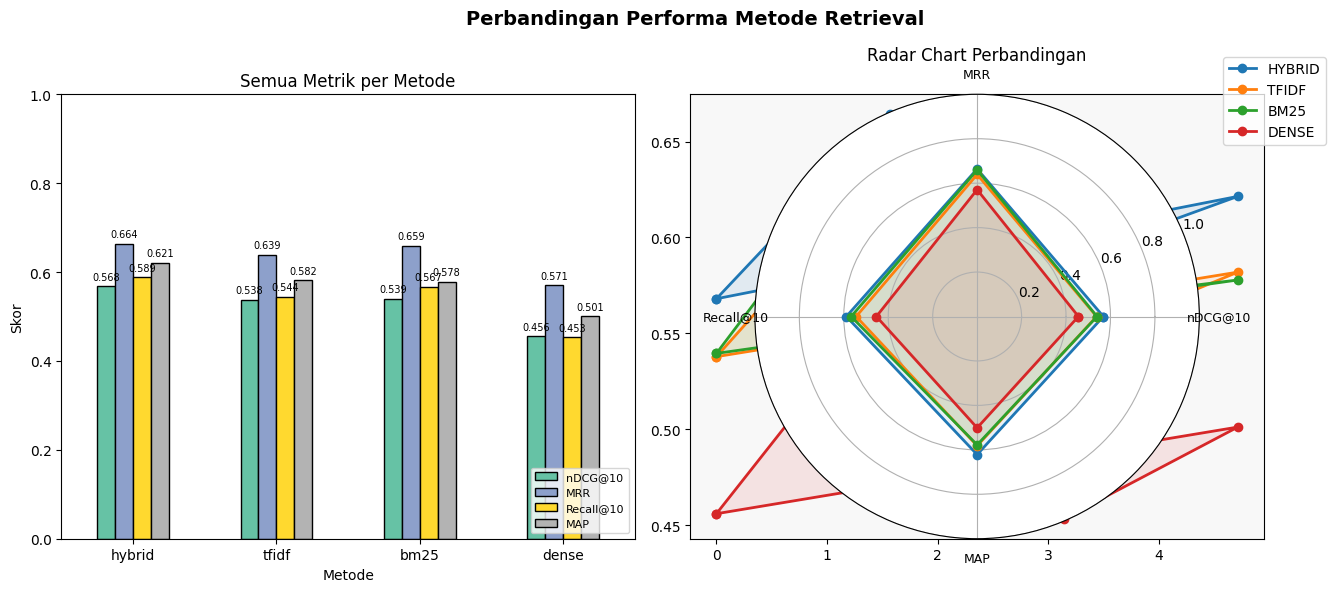

💾 Grafik disimpan di data/evaluation_results.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Perbandingan Performa Metode Retrieval', fontsize=14, fontweight='bold')

# Bar chart semua metrik
eval_df.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Semua Metrik per Metode')
axes[0].set_xlabel('Metode')
axes[0].set_ylabel('Skor')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 1.0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=7
    )

# Radar chart
from matplotlib.patches import FancyArrowPatch
metrics_names = list(eval_df.columns)
N = len(metrics_names)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[1].set_facecolor('#f8f8f8')

for i, (method, row) in enumerate(eval_df.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    axes[1].plot(angles, values, 'o-', linewidth=2, label=method.upper(), color=colors[i])
    axes[1].fill(angles, values, alpha=0.1, color=colors[i])

axes[1] = plt.subplot(122, polar=True)
axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(metrics_names, fontsize=9)
axes[1].set_title('Radar Chart Perbandingan')
axes[1].set_ylim(0, 1)

for i, (method, row) in enumerate(eval_df.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    axes[1].plot(angles, values, 'o-', linewidth=2, label=method.upper(), color=colors[i])
    axes[1].fill(angles, values, alpha=0.1, color=colors[i])

axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Grafik disimpan di data/evaluation_results.png")

In [10]:
# Tambahkan cell baru di evaluation.ipynb
k_values = [10, 30, 60, 100]
k_results = {}

for k_val in k_values:
    eval_results_k = {}
    for method in methods:
        relevances_per_query = {}
        total_relevant_per_query = {}
        for query in annotated_queries:
            qrels = annotations[query]
            total_relevant_per_query[query] = sum(qrels.values())
            # Re-run RRF dengan k berbeda
            from src.retrieval.fusion import reciprocal_rank_fusion
            if method == 'hybrid':
                t = results_all[query]['tfidf']
                b = results_all[query]['bm25']
                d = results_all[query]['dense']
                fused = reciprocal_rank_fusion([t, b, d], k=k_val)
                doc_ids = [doc_id for doc_id, _ in fused[:10]]
            else:
                doc_ids = results_all[query][method]
            relevances_per_query[query] = [
                qrels.get(str(doc_id), 0) for doc_id in doc_ids
            ]
        metrics = evaluate_all_metrics(
            relevances_per_query, total_relevant_per_query, k=10
        )
        eval_results_k[method] = metrics
    k_results[k_val] = eval_results_k

# Print tabel nDCG Hybrid untuk berbagai k
print("Pengaruh parameter k terhadap nDCG@10 (Hybrid):")
print(f"{'k':>6} | {'nDCG@10':>10} | {'MRR':>10}")
print("-" * 32)
for k_val in k_values:
    ndcg = k_results[k_val]['hybrid']['nDCG@10']
    mrr  = k_results[k_val]['hybrid']['MRR']
    print(f"{k_val:>6} | {ndcg:>10.4f} | {mrr:>10.4f}")

Pengaruh parameter k terhadap nDCG@10 (Hybrid):
     k |    nDCG@10 |        MRR
--------------------------------
    10 |     0.5605 |     0.6398
    30 |     0.5599 |     0.6425
    60 |     0.5599 |     0.6425
   100 |     0.5599 |     0.6425
